--- Model Evaluation ---
Accuracy Score: 76.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.60      0.67      0.63         9
   virginica       0.70      0.64      0.67        11

    accuracy                           0.77        30
   macro avg       0.77      0.77      0.77        30
weighted avg       0.77      0.77      0.77        30



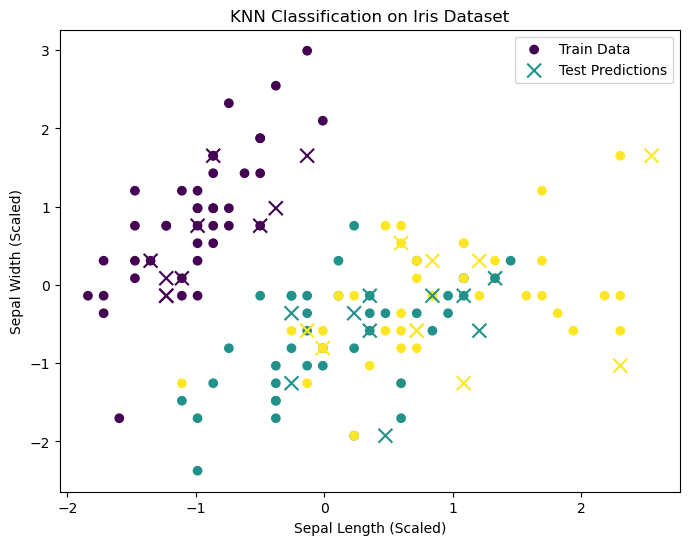

In [1]:
# 1. Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# 2. Load and Prepare Dataset
iris = load_iris()
X = iris.data[:, :2]  # Using first two features (Sepal Length, Sepal Width) for easy 2D plotting
y = iris.target

# 3. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Crucial for distance-based algorithms like KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Initialize and Train the Model
# We use an odd number for K (n_neighbors) to avoid ties
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# 6. Make Predictions and Evaluate
y_pred = model.predict(X_test)

print("--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 7. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, marker='x', s=100, cmap='viridis', label='Test Predictions')

plt.xlabel("Sepal Length (Scaled)")
plt.ylabel("Sepal Width (Scaled)")
plt.title("KNN Classification on Iris Dataset")
plt.legend()
plt.show()